In [1]:
from  langchain_community.document_loaders import PyPDFLoader
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings,OpenAI,ChatOpenAI
os.environ['OPENAI_API_KEY']=os.getenv("OPENAI_API_KEY")
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

c:\Users\USER\anaconda3\envs\rag_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ['OPENAI_API_KEY']=os.getenv("OPENAI_API_KEY")
from  langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

In [4]:
from typing import TypedDict,Optional

from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, END

In [5]:
class AgentState(TypedDict):
    question: str
    topic: str
    k :int
    chunks : list[str]
    documents: list
    answer: str

In [6]:
def build_vector_db(file_path):

    loader = PyPDFLoader(file_path)
    docs = loader.load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=100
    )

    chunks = splitter.split_documents(docs)
    pdf_name=os.path.splitext(os.path.basename(file_path))[0]
    persist_directory=os.path.join("db_books",pdf_name)

    vectordb = Chroma.from_documents(
        chunks,
        embeddings,
        persist_directory=persist_directory
    )

    return vectordb


In [ ]:
chess_db = build_vector_db(r"books/chess_guide.pdf")
medical_db = build_vector_db(r"books/medical_basics.pdf")
stock_db = build_vector_db(r"books/stock_market_basics.pdf")
cricket_db = build_vector_db(r"books/cricket_guide.pdf")

In [9]:
# define router 
def route_topic(state: AgentState):

    question = state["question"].lower()

    if "chess" in question:
        topic = "chess"

    elif "medicine" in question or "disease" in question:
        topic = "medical"

    elif "stock" in question or "trading" in question or 'investment' in question:
        topic = "stock"

    elif "cricket" in question:
        topic = "cricket"

    else:
       raise ValueError ("please select topics chess. medical stock or cricket")

    return {**state, "topic": topic}

In [28]:

# # this funcation we can used  once  will create new function that can retrive data from db 
#  def retrieve_docs(state: AgentState):

#     topic = state["topic"]
#     question = state["question"]

#     if topic == "chess":
#         db = chess_db

#     elif topic == "medical":
#         db = medical_db

#     elif topic == "stock":
#         db = stock_db

#     else:
#         db = cricket_db

#     docs = db.similarity_search(question, k=4)

#     return {**state, "documents": docs}


In [10]:
db_map = {
    "chess": "db_books/chess_guide",
    "medical": "db_books/medical_basics",
    "stock": "db_books/stock_market_basics",
    "cricket": "db_books/cricket_guide"
}

def retrive_chuks_from_db(state: AgentState) -> AgentState:
    "this funcion rertive chunks from vector database "
    
    question = state["question"]
    topic = state["topic"]
    k=state["k"]
    
    normalized_topic=topic.strip().lower()
    if normalized_topic not in db_map :
        raise ValueError( f"Invalid  topics  used topics {list(db_map.keys())}")
    
    vector_db = Chroma(
    embedding_function=embeddings,
    persist_directory=db_map[normalized_topic])

    docs=vector_db.similarity_search(question,k=k)
    chunks=[doc.page_content for doc in docs]
    return {
        "question" :question,
        "topic":normalized_topic,
        "chunks":chunks  
        
    }

    

In [11]:
def retrive_node(state: AgentState):
    
    result=retrive_chuks_from_db(state)
    return {**state, "chunks":result["chunks"]}

In [12]:
def generate_answer(state: AgentState):

    question = state["question"]
    docs=state['chunks']
    

    context = "\n\n".join([doc for doc in docs])

    prompt = f"""
    Answer the question using the context below.

    Context:
    {context}

    Question:
    {question}
    """

    response = llm.invoke(prompt)

    return {**state, "answer": response.content}

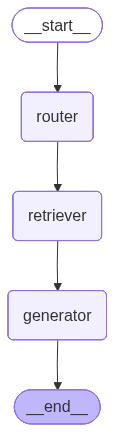

In [13]:

# -----------------------------
# BUILD LANGGRAPH
# -----------------------------

builder = StateGraph(AgentState)

builder.add_node("router", route_topic)
builder.add_node("retriever", retrive_node)
builder.add_node("generator", generate_answer)

builder.set_entry_point("router")

builder.add_edge("router", "retriever")
builder.add_edge("retriever", "generator")
builder.add_edge("generator", END)

graph = builder.compile()
graph


In [14]:

question = "Explain basic in chess"

result = graph.invoke({
    "question": question ,"k":1
})

print(result["answer"])

C:\Users\USER\AppData\Local\Temp\ipykernel_95508\1930279800.py:19: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_db = Chroma(


In chess, the basics involve understanding the game's objective, the pieces, and their movements. The game is played on an 8×8 board with 64 squares, and each player begins with 16 pieces: 1 King, 1 Queen, 2 Rooks, 2 Knights, 2 Bishops, and 8 Pawns. The primary objective of chess is to checkmate the opponent's king, which means placing it under threat of capture in such a way that it has no legal moves to escape.

Each type of chess piece has its own unique way of moving:

- **King**: Moves one square in any direction.
- **Queen**: Moves any number of squares in any direction.
- **Rook**: Moves any number of squares horizontally or vertically.

Understanding these basic movements and the goal of checkmate is essential for beginning to play chess strategically.


In [15]:

question = "investment in market "
result = graph.invoke({
    "question": question ,"k":1
})

print(result["answer"])

Investment in the stock market involves buying shares of publicly listed companies with the aim of making a profit. Investors seek to purchase stocks at lower prices and sell them at higher prices. They typically develop a portfolio, which is a collection of their various investments, to manage risk and optimize returns. The stock market serves as a marketplace (exchanges like NSE and BSE) where these buying and selling activities occur. There are various investment strategies that investors can employ to navigate this process effectively.
